<div align="center">

# Notebook SpecAug

# Classification multi-class FOCH avec SpecAugment

**Branche Dual pour la classification**

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)
![librosa](https://img.shields.io/badge/librosa-STFT%2FISTFT-9cf?style=flat-square)
![SpecAugment](https://img.shields.io/badge/SpecAugment-time%2Ffreq%20masking-orange?style=flat-square)
![Output](https://img.shields.io/badge/output-.wav-success?style=flat-square)

</div>


## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances et les chemins. Le notebook met en œuvre un **modèle de fusion bi-branche lourd** (WavLM-Large + ResNet101) évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Support intermédiaire |
| `fuite glottique` | FOCH | Support intermédiaire |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** (répertoire `Segmented_Voyelles_Augmented/signal`), injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

> 💡 **Rappel architecture** — Branche A = **WavLM-Large** local (embeddings gelés, 1024-d, microscopique) ; Branche B = **ResNet101** pré-entraîné ImageNet sur spectrogramme de Mel (2048-d post-GAP, macroscopique) → fusion **3072-d**. Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.

In [1]:
# Cellule 1 Imports, configuration des chemins et hyperparamètres

import os
import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# FFmpeg (backend de d?codage audio pour torchaudio) 
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# Manifeste unifié (originaux + SpecAugment augmenté)
# Colonnes : filepath, File_Name, Last_Name, label_str, is_aug, source_filepath
# is_aug=False  données de base pour le K-Fold
# is_aug=True   pool augmenté injecté uniquement dans le train de chaque pli
MANIFEST_PATH = r'C:/Users/AdminIA/Desktop/Foch_Classif_Final/data/augmentation_manifest_specaug.csv'

# Backbone et artefacts de sortie 
MODEL_DIR   = r'C:/Users/AdminIA/Documents/models/wavlm-large'
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_mètriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = 'wavlm_resnet101_kfold_specaug'

# Définition des classes 
# La classe 'Cancer' reste EXCLUE (support insuffisant, n > 26).
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)

# Validation croisée 
K_FOLDS      = 5

# Hyperparamètres audio 
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)

# Spectrogramme de Mel (Branche B) 
N_FFT        = 1024
HOP_LENGTH   = 256
N_MELS       = 128
MEL_FRAMES   = MAX_LEN // HOP_LENGTH + 1

# Hyperparamètres d'entra?nement 
BATCH_SIZE      = 4
ACCUM_STEPS     = 4
EPOCHS          = 30
LR              = 1e-4
WEIGHT_DECAY    = 0.01
PATIENCE        = 6
DROPOUT         = 0.3
HIDDEN_DIM      = 512
FREEZE_WAVLM    = True
RESNET_PRETRAINED = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Configuration charg?e.')
print(f'  Classes ({NUM_LABELS}) : {CLASSES}')
print(f'  Manifeste       : {MANIFEST_PATH}')
print(f'  Validation      : StratifiedKFold ? {K_FOLDS} plis')
print(f'  Backbone audio  : {MODEL_DIR}')
print(f'  Mel             : n_fft={N_FFT}, hop={HOP_LENGTH}, n_mels={N_MELS} ? ({N_MELS}, {MEL_FRAMES})')
print(f'  Fusion          : 1024 (WavLM) + 2048 (ResNet101) = 3072')
print(f'  Device          : {device}')

FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration charg?e.
  Classes (4) : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Manifeste       : C:/Users/AdminIA/Desktop/Foch_Classif_Final/data/augmentation_manifest_specaug.csv
  Validation      : StratifiedKFold ? 5 plis
  Backbone audio  : C:/Users/AdminIA/Documents/models/wavlm-large
  Mel             : n_fft=1024, hop=256, n_mels=128 ? (128, 251)
  Fusion          : 1024 (WavLM) + 2048 (ResNet101) = 3072
  Device          : cuda


## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# Cellule 2  Chargement et nettoyage depuis le manifeste unifié

#  1. Lecture du manifeste 
man = pd.read_csv(MANIFEST_PATH)
print(f'Manifeste brut : {len(man)} lignes')

for col in ['filepath', 'File_Name', 'Last_Name', 'label_str', 'is_aug']:
    man[col] = man[col].astype(str).str.strip()
man['is_aug_bool'] = man['is_aug'].str.lower() == 'true'

# 2. Filtre sur les classes cibles 
man_filtered = man[man['label_str'].isin(CLASSES)].copy()
print(f'Lignes retenues (classes cibles) : {len(man_filtered)}')

# 3. Données de base (is_aug=False) base du K-Fold 
# Déduplication patient sur Last_Name pour éviter toute fuite train/validation.
# NB : Last_Name est un proxy à des homonymes (ex. MARTIN) peuvent être fusionn?s
#      à tort ; à auditer ultérieurement via patient_id si disponible.
df_base = man_filtered[~man_filtered['is_aug_bool']].copy()
n_avant = len(df_base)
df_base = df_base.drop_duplicates(subset='Last_Name', keep='first')
print(f'Aprés déduplication patient    : {len(df_base):>4}  ({n_avant - len(df_base)} doublon(s) retir?(s))')

df_base['exists'] = df_base['filepath'].apply(os.path.isfile)
n_missing = int((~df_base['exists']).sum())
if n_missing:
    print(f'?  {n_missing} fichier(s) introuvable(s) sur disque ? exclus.')
df_base = df_base[df_base['exists']]
df = df_base[['filepath', 'File_Name', 'Last_Name', 'label_str']].reset_index(drop=True)

print('\n' + '=' * 60)
print('Répartition des classes (base, is_aug=False) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Manifeste brut : 595 lignes
Lignes retenues (classes cibles) : 595
Aprés déduplication patient    :  265  (0 doublon(s) retir?(s))

Répartition des classes (base, is_aug=False) :
label_str
PR                  72
LMB                 67
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 265 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  72
1      LMB                 67
2      fuite glottique     26
3      Healthy            100


## 4. Processor WavLM et `Dataset` bi-branche

Le `Dataset` encapsule la chaîne de prétraitement et produit, pour chaque enregistrement, les **deux entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding ;
2. **Branche A (WavLM)** — extraction de features via le `Wav2Vec2FeatureExtractor` (normalisation + padding) → `input_values` ;
3. **Branche B (Mel)** — `MelSpectrogram` → conversion en dB (`AmplitudeToDB`) → normalisation par échantillon → image temps-fréquence à 1 canal `(1, n_mels, T)`.

> 🛡️ **Robustesse** — un fichier corrompu ne doit jamais interrompre l'entraînement : un bloc `try/except` renvoie des tenseurs nuls de secours (forme d'onde + Mel) en signalant le fichier fautif.

> ℹ️ WavLM réutilise l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe « WavLMFeatureExtractor » dédiée.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processor WavLM + Dataset bi-branche (WavLM input + Mel)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# WavLM réutilise l'extracteur de features de Wav2Vec2 (normalisation + padding).
processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_DIR)
print(f'✓ Processor chargé : {type(processor).__name__}')


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit DEUX représentations pour
    le modèle de fusion bi-branche :

      • `input_values` — forme d'onde brute (16 kHz, normalisée) destinée à la
        Branche A (WavLM-Large), via le `Wav2Vec2FeatureExtractor` ;
      • `mel`          — spectrogramme de Mel en dB, normalisé, destiné à la
        Branche B (ResNet18) sous forme d'image temps-fréquence à 1 canal.

    La forme d'onde est d'abord ramenée mono + 16 kHz + longueur fixe `MAX_LEN`,
    de sorte que les deux branches reçoivent des tenseurs de dimensions constantes
    (collate par défaut). Renvoie le triplet (input_values, mel, label)."""

    def __init__(self, dataframe, processor, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.sr        = target_sr
        self.max_len   = max_len
        # Transformées Mel (instanciées une fois, partagées par tous les items).
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=target_sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype='power', top_db=80.0)

    def __len__(self):
        return len(self.df)

    def _fixed_length(self, wave):
        """Tronque ou complète (zéro-padding) la forme d'onde à `max_len`."""
        n = wave.shape[-1]
        if n >= self.max_len:
            return wave[..., :self.max_len]
        return torch.nn.functional.pad(wave, (0, self.max_len - n))

    def _mel(self, wave):
        """Spectrogramme de Mel → dB → normalisation par échantillon → (1, n_mels, T)."""
        mel = self.to_db(self.mel_transform(wave))
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        return mel.unsqueeze(0)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            waveform, orig_sr = torchaudio.load(row['filepath'])
            if waveform.shape[0] > 1:                                   # stéréo → mono
                waveform = waveform.mean(dim=0, keepdim=True)
            if orig_sr != self.sr:                                      # ré-échantillonnage
                waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
            wave = self._fixed_length(waveform.squeeze(0))              # (MAX_LEN,)

            # ── Branche A : WavLM (normalisation + padding via le processor) ──
            out = self.processor(
                wave.numpy(),
                sampling_rate=self.sr,
                max_length=self.max_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
            )
            input_values = out.input_values.squeeze(0)                  # (MAX_LEN,)

            # ── Branche B : spectrogramme de Mel ─────────────────────────────
            mel = self._mel(wave)                                       # (1, N_MELS, T)
        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len)
            mel          = torch.zeros(1, N_MELS, MEL_FRAMES)
        return input_values, mel, torch.tensor(label, dtype=torch.long)


print(f'Fenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
print(f'Spectrogramme de Mel : (1, {N_MELS}, {MEL_FRAMES})')

✓ Processor chargé : Wav2Vec2FeatureExtractor
Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Spectrogramme de Mel : (1, 128, 251)


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On remplace le découpage train/val unique par une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6).

In [5]:
# Cellule 5 Préparation de la validation croisée (StratifiedKFold) + pool augmenté

from sklearn.model_selection import StratifiedKFold

# 1. Plis de validation croisée stratifiée
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# 2. Construction du pool augmenté (is_aug=True) 
# Les segments augmentés (SpecAugment .wav) sont injectés pli par pli
# UNIQUEMENT dans le train, après exclusion des patients présents en validation.
aug_raw = man_filtered[man_filtered['is_aug_bool']].copy()
aug_raw['label'] = aug_raw['label_str'].map(label2id)
aug_raw = aug_raw.dropna(subset=['label'])
aug_raw['label'] = aug_raw['label'].astype(int)
aug_raw['exists'] = aug_raw['filepath'].apply(os.path.isfile)
n_missing = int((~aug_raw['exists']).sum())
if n_missing:
    print(f'  ? {n_missing} fichier(s) augmenté(s) introuvable(s) à écarté(s)')
aug_df = aug_raw[aug_raw['exists']][['filepath', 'File_Name', 'Last_Name', 'label_str', 'label']].reset_index(drop=True)

print(f'\nPool augmenté disponible : {len(aug_df)} segments')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())

# 3. Batch sonde 
_probe_loader = DataLoader(FochVowelDataset(df.head(BATCH_SIZE), processor),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, mb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde à WavLM : {tuple(xb.shape)} | Mel : {tuple(mb.shape)} | labels : {yb.tolist()}')

StratifiedKFold : 5 plis générés sur 265 enregistrements originaux.
  Pli 1 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=212 | val=53 | val par classe={'PR': 14, 'LMB': 13, 'fuite glottique': 6, 'Healthy': 20}
  Pli 4 : train=212 | val=53 | val par classe={'PR': 14, 'LMB': 14, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=53 | val par classe={'PR': 14, 'LMB': 14, 'fuite glottique': 5, 'Healthy': 20}

Pool augmenté disponible : 330 segments
label_str
PR                  60
LMB                 90
fuite glottique    120
Healthy             60

Batch sonde à WavLM : (4, 64000) | Mel : (4, 1, 128, 251) | labels : [0, 0, 2, 0]


## 6. Modèle de fusion bi-branche (WavLM-Large + ResNet101)

Réseau **bi-branche** dont les représentations globales sont concaténées avant la tête de classification. Une fonction `build_model()` permet de réinitialiser une instance neuve à chaque pli de la validation croisée.

### Branche A — Acoustique microscopique (`WavLM-Large`)
Backbone **WavLM-Large** local, **gelé** (extraction d'embeddings). Moyenne temporelle des états cachés → vecteur **1024-d**. Cible : jitter, shimmer, apériodicité court-terme.

### Branche B — Événements macroscopiques (`ResNet101`)
**ResNet101 pré-entraîné sur ImageNet**, appliqué au **spectrogramme de Mel**. Le Mel mono-canal est **répliqué sur 3 canaux** pour exploiter pleinement la première convolution pré-entraînée ; le Global Average Pooling fournit un vecteur **2048-d**. Cible : étalement formantique, bandes de bruit, perte de structures harmoniques.

### Fusion & tête de classification
Concaténation des deux vecteurs (**1024 + 2048 = 3072**), puis séquence **Linear(3072→`HIDDEN_DIM`) → BatchNorm → Dropout → ReLU → Linear(`HIDDEN_DIM`→`NUM_LABELS`)**. Une vérification dimensionnelle est exécutée sur le batch sonde, puis la mémoire GPU est libérée.

> ⚠️ Si les poids ImageNet sont indisponibles (exécution hors-ligne sans cache), ResNet101 retombe sur une initialisation aléatoire (`weights=None`) avec un avertissement. Seuls ResNet101 et la tête de fusion sont entraînés (WavLM gelé).

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion bi-branche (WavLM-Large + ResNet101)
# ═══════════════════════════════════════════════════════════════════════════
import torchvision
from transformers import WavLMModel


class DualBranchFusion(nn.Module):
    """Classifieur de fusion à deux branches complémentaires.

    • Branche A — WavLM-Large (gelé) : capture les variations acoustiques
      microscopiques (jitter, shimmer, apériodicité court-terme). Les états
      cachés du transformer sont agrégés par moyenne temporelle → 1024.

    • Branche B — ResNet101 (pré-entraîné ImageNet) sur spectrogramme de Mel :
      capture les événements macroscopiques temps-fréquence (étalement
      formantique, bandes de bruit, perte de structures harmoniques). Le Mel
      mono-canal est répliqué sur 3 canaux pour exploiter pleinement la première
      convolution pré-entraînée ; le Global Average Pooling fournit un vecteur
      de dimension 2048.

    • Fusion — concaténation des deux représentations (1024 + 2048 = 3072), puis
      tête Linear(3072→HIDDEN_DIM) → BatchNorm → Dropout → ReLU →
      Linear(HIDDEN_DIM→NUM_LABELS).
    """

    def __init__(self, wavlm_dir, num_labels, freeze_wavlm=FREEZE_WAVLM,
                 resnet_pretrained=RESNET_PRETRAINED, dropout=DROPOUT, hidden=HIDDEN_DIM):
        super().__init__()

        # ── Branche A : WavLM-Large ──────────────────────────────────────────
        self.wavlm        = WavLMModel.from_pretrained(wavlm_dir)
        self.freeze_wavlm = freeze_wavlm
        if freeze_wavlm:
            self.wavlm.eval()
            for p in self.wavlm.parameters():
                p.requires_grad = False
        wavlm_dim = self.wavlm.config.hidden_size                      # 1024

        # ── Branche B : ResNet101 (entrée 3 canaux ← Mel répliqué) ───────────
        weights = None
        if resnet_pretrained:
            try:
                weights = torchvision.models.ResNet101_Weights.IMAGENET1K_V2
            except Exception as e:
                print(f'[ResNet101] poids ImageNet indisponibles ({e}) → init aléatoire.')
        resnet = torchvision.models.resnet101(weights=weights)
        resnet_dim  = resnet.fc.in_features                            # 2048
        resnet.fc   = nn.Identity()                                    # vecteur post-GAP (2048)
        self.resnet = resnet

        # ── Tête de fusion + classification ──────────────────────────────────
        fusion_dim = wavlm_dim + resnet_dim                            # 3072
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_labels),
        )
        self.fusion_dim = fusion_dim

    def train(self, mode=True):
        """Maintient WavLM en mode `eval` lorsqu'il est gelé (BatchNorm/dropout figés)."""
        super().train(mode)
        if self.freeze_wavlm:
            self.wavlm.eval()
        return self

    def forward(self, input_values, mel):
        # ── Branche A : embeddings WavLM, moyenne temporelle → (B, 1024) ─────
        if self.freeze_wavlm:
            with torch.no_grad():
                feat_a = self.wavlm(input_values).last_hidden_state
        else:
            feat_a = self.wavlm(input_values).last_hidden_state
        feat_a = feat_a.mean(dim=1)

        # ── Branche B : Mel (1 canal) → 3 canaux → ResNet101 → (B, 2048) ─────
        feat_b = self.resnet(mel.repeat(1, 3, 1, 1))

        # ── Fusion par concaténation → tête de classification ────────────────
        fused = torch.cat([feat_a, feat_b], dim=1)                     # (B, 3072)
        return self.classifier(fused)


def build_model():
    """Fabrique une instance neuve du modèle (réinitialisée à chaque pli)."""
    return DualBranchFusion(MODEL_DIR, NUM_LABELS)


# ── Vérification dimensionnelle sur le batch sonde, puis libération mémoire ──
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Dimension de fusion     : {_m.fusion_dim} (1024 WavLM + 2048 ResNet101)')
print(f'Paramètres totaux       : {_total:,}')
print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.1f} %)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')

_m.eval()
with torch.no_grad():
    _logits = _m(xb.to(device), mb.to(device))
print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({xb.shape[0]}, {NUM_LABELS}))')
assert _logits.shape == (xb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

Loading weights: 100%|██████████| 488/488 [00:00<00:00, 32450.07it/s]


Dimension de fusion     : 3072 (1024 WavLM + 2048 ResNet101)
Paramètres totaux       : 359,529,732
Paramètres entraînables : 44,076,612  (12.3 %)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']
Sortie logits (test)    : (4, 4)  (attendu : (4, 4))


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

L'entraînement, la validation et la collecte des prédictions sont entièrement encapsulés dans la **boucle sur les K plis**. Pour chaque pli :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **Réinitialisation** — `build_model()` fournit un modèle neuf ; `AdamW` n'optimise que les paramètres entraînables (ResNet101 + tête ; WavLM gelé).
3. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping** sur la perte de validation (meilleur modèle sauvegardé par pli).
4. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
5. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis pour éviter l'OOM sur ResNet101.

Les métriques par pli sont agrégées en fin de cellule (moyenne ± écart-type).

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

criterion = nn.CrossEntropyLoss()
labels_idx = np.arange(NUM_LABELS)

# Conteneurs out-of-fold : chaque enregistrement original est prédit exactement
# une fois (lorsqu'il appartient au pli de validation).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])

    # Injection des données augmentées : UNIQUEMENT dans le train, en écartant
    # tout segment issu d'un patient présent dans le pli de validation.
    aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)

    # Garde-fou : le pli de validation reste strictement original et sans fuite.
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    train_loader = DataLoader(FochVowelDataset(train_full, processor), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(FochVowelDataset(val_df, processor), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────────
    model     = build_model().to(device)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=LR, weight_decay=WEIGHT_DECAY)
    total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    scaler      = GradScaler()

    ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    best_val_loss, patience_ctr, val_hist = float('inf'), 0, []

    for epoch in range(EPOCHS):
        # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb, mb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb, mb)
                loss   = criterion(logits, yb) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb).sum().item()
            tot   += yb.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)

        # ── VALIDATION (pleine précision : ResNet101 profond → on évite tout ──
        #    dépassement fp16 qui produirait une perte NaN) ───────────────────
        model.eval()
        ep_v, corr_v, tot_v = 0.0, 0, 0
        with torch.no_grad():
            for xb, mb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                mb = mb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                logits = model(xb, mb)
                loss   = criterion(logits, yb)
                ep_v   += loss.item()
                corr_v += (logits.argmax(1) == yb).sum().item()
                tot_v  += yb.size(0)
        avg_v = ep_v / len(val_loader)
        val_hist.append(avg_v)
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val {avg_v:.4f}/{corr_v/tot_v:.3f}')

        if avg_v < best_val_loss:
            best_val_loss, patience_ctr = avg_v, 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                break

    # Garde-fou : si aucune amélioration finie n'a été enregistrée, on sauvegarde
    # tout de même le dernier état pour permettre le rechargement ci-dessous.
    if not os.path.exists(ckpt):
        torch.save(model.state_dict(), ckpt)

    # ── Prédictions out-of-fold (meilleur modèle du pli, pleine précision) ───
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb, mb, yb in val_loader:
            xb = xb.to(device); mb = mb.to(device)
            probs_list.append(F.softmax(model(xb, mb), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)                      # ordre = val_df (shuffle=False)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_loss': best_val_loss})
    fold_curves.append(val_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    # ── Libération mémoire avant le pli suivant (évite l'OOM sur ResNet101) ──
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')


PLI 1/5
Train 475 (orig 212 + aug 263) | Val 53 (original uniquement)


Loading weights: 100%|██████████| 488/488 [00:00<00:00, 33571.49it/s]


  Epoch 01/30 | Train 1.4513/0.280 | Val 11.8181/0.396
  Epoch 02/30 | Train 1.3018/0.434 | Val 44.2470/0.547
  Epoch 03/30 | Train 1.1184/0.542 | Val 53.0505/0.623
  Epoch 04/30 | Train 0.9619/0.604 | Val 69.0667/0.642
  Epoch 05/30 | Train 0.8347/0.684 | Val 3.8218/0.717
  Epoch 06/30 | Train 0.7224/0.716 | Val 24.4900/0.830
  Epoch 07/30 | Train 0.5960/0.786 | Val 2.7100/0.736
  Epoch 08/30 | Train 0.5422/0.805 | Val 10.0282/0.774
  Epoch 09/30 | Train 0.3900/0.854 | Val 1.7037/0.811
  Epoch 10/30 | Train 0.3824/0.862 | Val 5.1123/0.774
  Epoch 11/30 | Train 0.4074/0.858 | Val 13.4431/0.792
  Epoch 12/30 | Train 0.2850/0.915 | Val 8.4373/0.830
  Epoch 13/30 | Train 0.3447/0.888 | Val 11.2386/0.811
  Epoch 14/30 | Train 0.2595/0.917 | Val 3.3434/0.755
  Epoch 15/30 | Train 0.2588/0.911 | Val 1.5585/0.736
  Epoch 16/30 | Train 0.2363/0.926 | Val 3.2021/0.774
  Epoch 17/30 | Train 0.2047/0.947 | Val 2.7711/0.755
  Epoch 18/30 | Train 0.1954/0.943 | Val 1.6671/0.717
  Epoch 19/30 | Trai

Loading weights: 100%|██████████| 488/488 [00:00<00:00, 38686.41it/s]


  Epoch 01/30 | Train 1.4315/0.290 | Val 11.0337/0.264
  Epoch 02/30 | Train 1.2714/0.417 | Val 17.3176/0.472
  Epoch 03/30 | Train 1.1242/0.534 | Val 24.8516/0.585
  Epoch 04/30 | Train 0.9380/0.617 | Val 23.0617/0.585
  Epoch 05/30 | Train 0.8330/0.689 | Val 21.9802/0.604
  Epoch 06/30 | Train 0.7114/0.739 | Val 6.9647/0.660
  Epoch 07/30 | Train 0.5535/0.801 | Val 13.5111/0.623
  Epoch 08/30 | Train 0.5160/0.824 | Val 5.0363/0.679
  Epoch 09/30 | Train 0.4639/0.843 | Val 3.7892/0.660
  Epoch 10/30 | Train 0.3505/0.879 | Val 2.9467/0.660
  Epoch 11/30 | Train 0.2868/0.905 | Val 4.4615/0.623
  Epoch 12/30 | Train 0.3012/0.890 | Val 1.1616/0.717
  Epoch 13/30 | Train 0.2548/0.913 | Val 1.5826/0.698
  Epoch 14/30 | Train 0.2224/0.917 | Val 1.7950/0.642
  Epoch 15/30 | Train 0.2089/0.932 | Val 27.9851/0.660
  Epoch 16/30 | Train 0.2168/0.928 | Val 6.7330/0.642
  Epoch 17/30 | Train 0.1352/0.962 | Val 6.8138/0.642
  Epoch 18/30 | Train 0.1877/0.951 | Val 4.7134/0.660
  Arrêt anticipé à l'

...

  Epoch 01/30 | Train 1.4774/0.233 | Val 1.3742/0.283
  Epoch 02/30 | Train 1.2690/0.440 | Val 1.0125/0.585
  Epoch 03/30 | Train 1.0738/0.551 | Val 1.0153/0.679
  Epoch 04/30 | Train 0.9006/0.622 | Val 0.8281/0.660
  Epoch 05/30 | Train 0.7650/0.690 | Val 0.8641/0.717
  Epoch 06/30 | Train 0.6212/0.771 | Val 0.8649/0.679
  Epoch 07/30 | Train 0.4610/0.844 | Val 0.8685/0.736
  Epoch 08/30 | Train 0.3917/0.863 | Val 0.7896/0.736
  Epoch 09/30 | Train 0.4324/0.853 | Val 0.9114/0.717
  Epoch 10/30 | Train 0.4257/0.842 | Val 0.8471/0.774
  Epoch 11/30 | Train 0.2731/0.929 | Val 0.9583/0.717
  Epoch 12/30 | Train 0.2784/0.908 | Val 0.7832/0.736
  Epoch 13/30 | Train 0.2503/0.921 | Val 0.8480/0.755
  Epoch 14/30 | Train 0.1655/0.955 | Val 0.9277/0.717
  Epoch 15/30 | Train 0.2693/0.919 | Val 0.9373/0.774
  Epoch 16/30 | Train 0.2346/0.942 | Val 0.8358/0.774
  Epoch 17/30 | Train 0.1848/0.938 | Val 0.9154/0.736
  Epoch 18/30 | Train 0.1323/0.972 | Val 1.0348/0.774
  Arrêt anticipé à l'epoch 1

Loading weights: 100%|██████████| 488/488 [00:00<00:00, 44306.35it/s]


  Epoch 01/30 | Train 1.4127/0.302 | Val 6.7092/0.415
  Epoch 02/30 | Train 1.2425/0.456 | Val 89.8908/0.623
  Epoch 03/30 | Train 1.1093/0.521 | Val 63.6566/0.642
  Epoch 04/30 | Train 0.9279/0.625 | Val 11.8302/0.698
  Epoch 05/30 | Train 0.8024/0.702 | Val 8.2552/0.774
  Epoch 06/30 | Train 0.6037/0.796 | Val 13.8306/0.698
  Epoch 07/30 | Train 0.5128/0.825 | Val 38.1668/0.698
  Arrêt anticipé à l'epoch 7.
  → Pli 4 : Balanced Acc 0.339 | Macro-F1 0.305 | Macro AUC 0.617

PLI 5/5
Train 478 (orig 212 + aug 266) | Val 53 (original uniquement)


Loading weights: 100%|██████████| 488/488 [00:00<00:00, 20328.14it/s]


  Epoch 01/30 | Train 1.4506/0.244 | Val 34.0118/0.283
  Epoch 02/30 | Train 1.2441/0.450 | Val 16.7297/0.415
  Epoch 03/30 | Train 1.0504/0.576 | Val 11.1420/0.585
  Epoch 04/30 | Train 0.9243/0.624 | Val 23.8452/0.585
  Epoch 05/30 | Train 0.7557/0.706 | Val 8.3979/0.528
  Epoch 06/30 | Train 0.7120/0.729 | Val 26.1711/0.604
  Epoch 07/30 | Train 0.5191/0.836 | Val 5.1916/0.642
  Epoch 08/30 | Train 0.4869/0.840 | Val 10.3026/0.717
  Epoch 09/30 | Train 0.4002/0.878 | Val 23.0929/0.717
  Epoch 10/30 | Train 0.3435/0.889 | Val 33.6759/0.698
  Epoch 11/30 | Train 0.3785/0.868 | Val 20.9486/0.755
  Epoch 12/30 | Train 0.3217/0.893 | Val 31.9569/0.698
  Epoch 13/30 | Train 0.2177/0.931 | Val 35.3160/0.660
  Arrêt anticipé à l'epoch 13.
  → Pli 5 : Balanced Acc 0.543 | Macro-F1 0.544 | Macro AUC 0.821

Validation croisée terminée — synthèse par pli :
 fold  balanced_accuracy  macro_f1  macro_auc_ovr  n_train  n_aug  n_val  best_val_loss
    1           0.700641  0.681319       0.904025   

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Courbes ROC OvR** | Vue clinique des compromis sensibilité / spécificité par classe |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

Le tableau de bord agrège la matrice de confusion OOF (brute), les courbes ROC OvR, les métriques par pli et les courbes de perte de validation de chaque pli. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`.

Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.547     0.486     0.515        72
            LMB      0.672     0.582     0.624        67
fuite glottique      0.250     0.231     0.240        26
        Healthy      0.773     0.920     0.840       100

       accuracy                          0.649       265
      macro avg      0.561     0.555     0.555       265
   weighted avg      0.635     0.649     0.638       265

OOF global        — Balanced Acc 0.5547 | Macro-F1 0.5547 | Macro AUC 0.8145
Moyenne par pli   — Balanced Acc 0.5577±0.1346 | Macro-F1 0.5435±0.1428 | Macro AUC 0.8053±0.1109


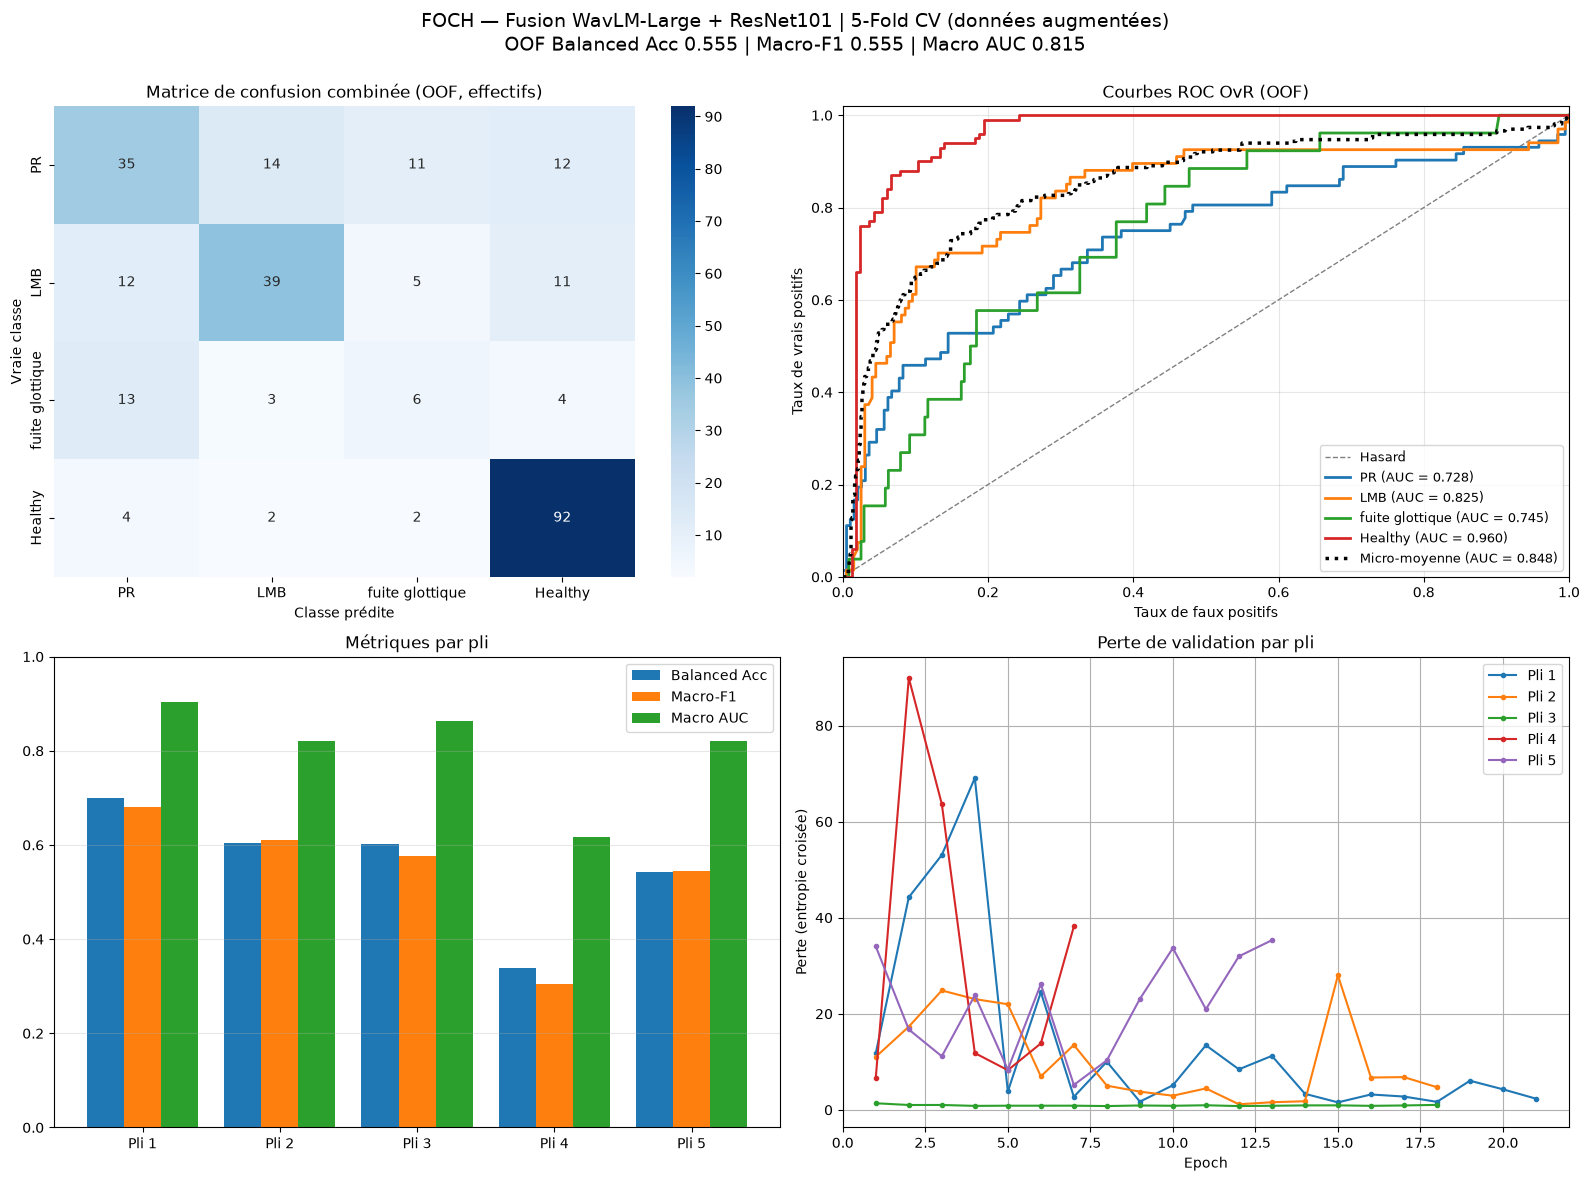


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_mètriques :
  • wavlm_resnet101_kfold_specaug_dashboard.png
  • wavlm_resnet101_kfold_specaug_metrics.json
  • wavlm_resnet101_kfold_specaug_confusion.csv
  • wavlm_resnet101_kfold_specaug_fold_metrics.csv


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold)
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score,
    f1_score, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

# Tous les enregistrements ont été prédits une fois (en validation de leur pli).
assert (oof_labels >= 0).all(), 'Des enregistrements n\'ont pas été évalués !'

# ── Métriques agrégées sur l'ensemble des prédictions out-of-fold ────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

# Moyennes des métriques calculées pli par pli (avec dispersion).
mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── Préparation ROC OvR ───────────────────────────────────────────────────────
y_bin = label_binarize(oof_labels, classes=labels_idx)
roc_fpr, roc_tpr, roc_auc = {}, {}, {}
for i, class_name in enumerate(CLASSES):
    roc_fpr[i], roc_tpr[i], _ = roc_curve(y_bin[:, i], oof_probs[:, i])
    roc_auc[i] = auc(roc_fpr[i], roc_tpr[i])
roc_fpr['micro'], roc_tpr['micro'], _ = roc_curve(y_bin.ravel(), oof_probs.ravel())
roc_auc['micro'] = auc(roc_fpr['micro'], roc_tpr['micro'])

# ── Tableau de bord 2×2 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'FOCH — Fusion WavLM-Large + ResNet101 | {K_FOLDS}-Fold CV (données augmentées)\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=14)

# Matrice de confusion combinée (toutes prédictions out-of-fold confondues).
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)')
axes[0, 0].set_ylabel('Vraie classe'); axes[0, 0].set_xlabel('Classe prédite')

# Courbes ROC OvR basées sur les probabilités out-of-fold.
axes[0, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Hasard')
for i, class_name in enumerate(CLASSES):
    axes[0, 1].plot(
        roc_fpr[i],
        roc_tpr[i],
        linewidth=2,
        label=f'{class_name} (AUC = {roc_auc[i]:.3f})',
    )
axes[0, 1].plot(
    roc_fpr['micro'],
    roc_tpr['micro'],
    color='black',
    linewidth=2.5,
    linestyle=':',
    label=f'Micro-moyenne (AUC = {roc_auc["micro"]:.3f})',
)
axes[0, 1].set_title('Courbes ROC OvR (OOF)')
axes[0, 1].set_xlabel('Taux de faux positifs')
axes[0, 1].set_ylabel('Taux de vrais positifs')
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1.02)
axes[0, 1].legend(loc='lower right', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Métriques par pli (moyenne ± écart-type en titre).
x = np.arange(K_FOLDS); w = 0.27
axes[1, 0].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[1, 0].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[1, 0].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[1, 0].set_title('Métriques par pli')
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[1, 0].set_ylim(0, 1); axes[1, 0].legend(); axes[1, 0].grid(True, axis='y', alpha=0.3)

# Courbes de perte de validation par pli.
for k, hist in enumerate(fold_curves):
    axes[1, 1].plot(range(1, len(hist) + 1), hist, 'o-', label=f'Pli {k+1}', markersize=3)
axes[1, 1].set_title('Perte de validation par pli')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Perte (entropie croisée)')
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout(); plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts d'évaluation ────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':          RUN_NAME,
    'architecture':      'DualBranchFusion (WavLM-Large + ResNet101)',
    'cv':                f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy': oof_bal,
    'oof_macro_f1':          oof_mf1,
    'oof_macro_auc_ovr':     oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':          fold_rows,
    'per_class_oof':     report_dict,
    'classes':           CLASSES,
    'n_total':           int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')

## 9. Inférence par ensemble des K plis

Au lieu de se fier à un unique modèle de pli, on **charge les K checkpoints**
sauvegardés à la Cellule 7 et on **moyenne leurs probabilités softmax**
échantillon par échantillon. Cette stratégie réduit la variance inter-plis
observée en Cellule 8 (fold 2 = 0,759 vs fold 5 = 0,584) sans aucun
ré-entraînement.

La fonction `ensemble_predict(dataloader, checkpoints)` est conçue pour être
réutilisée sur de **nouvelles données** : elle est indépendante de la structure
des plis d'entraînement.

> ⚠️ L'évaluation ci-dessous porte sur le **jeu complet** (265 enregistrements) :
> chaque échantillon a été vu par K-1 = 4 modèles sur 5, ce qui rend le résultat
> légèrement optimiste. Les métriques OOF de la Cellule 8 restent la référence
> non biaisée pour comparer les runs entre eux.

5 checkpoints détectés :
  C:/Users/AdminIA/Documents/models/.poids_modèles\wavlm_resnet101_kfold_specaug_fold1_best.pt
  C:/Users/AdminIA/Documents/models/.poids_modèles\wavlm_resnet101_kfold_specaug_fold2_best.pt
  C:/Users/AdminIA/Documents/models/.poids_modèles\wavlm_resnet101_kfold_specaug_fold3_best.pt
  C:/Users/AdminIA/Documents/models/.poids_modèles\wavlm_resnet101_kfold_specaug_fold4_best.pt
  C:/Users/AdminIA/Documents/models/.poids_modèles\wavlm_resnet101_kfold_specaug_fold5_best.pt
Inférence ensemble en cours (5 modèles × 265 échantillons)...


Loading weights: 100%|██████████| 488/488 [00:00<00:00, 14555.17it/s]



Ensemble (5 plis) vs OOF individuel :
  Balanced Acc : 0.9514  (OOF : 0.5547  Δ +0.3967)
  Macro-F1     : 0.9427  (OOF : 0.5547  Δ +0.3880)
  Macro AUC    : 0.9963  (OOF : 0.8145  Δ +0.1818)
------------------------------------------------------------
                 precision    recall  f1-score   support

             PR      0.985     0.889     0.934        72
            LMB      0.901     0.955     0.928        67
fuite glottique      0.862     0.962     0.909        26
        Healthy      1.000     1.000     1.000       100

       accuracy                          0.955       265
      macro avg      0.937     0.951     0.943       265
   weighted avg      0.957     0.955     0.955       265



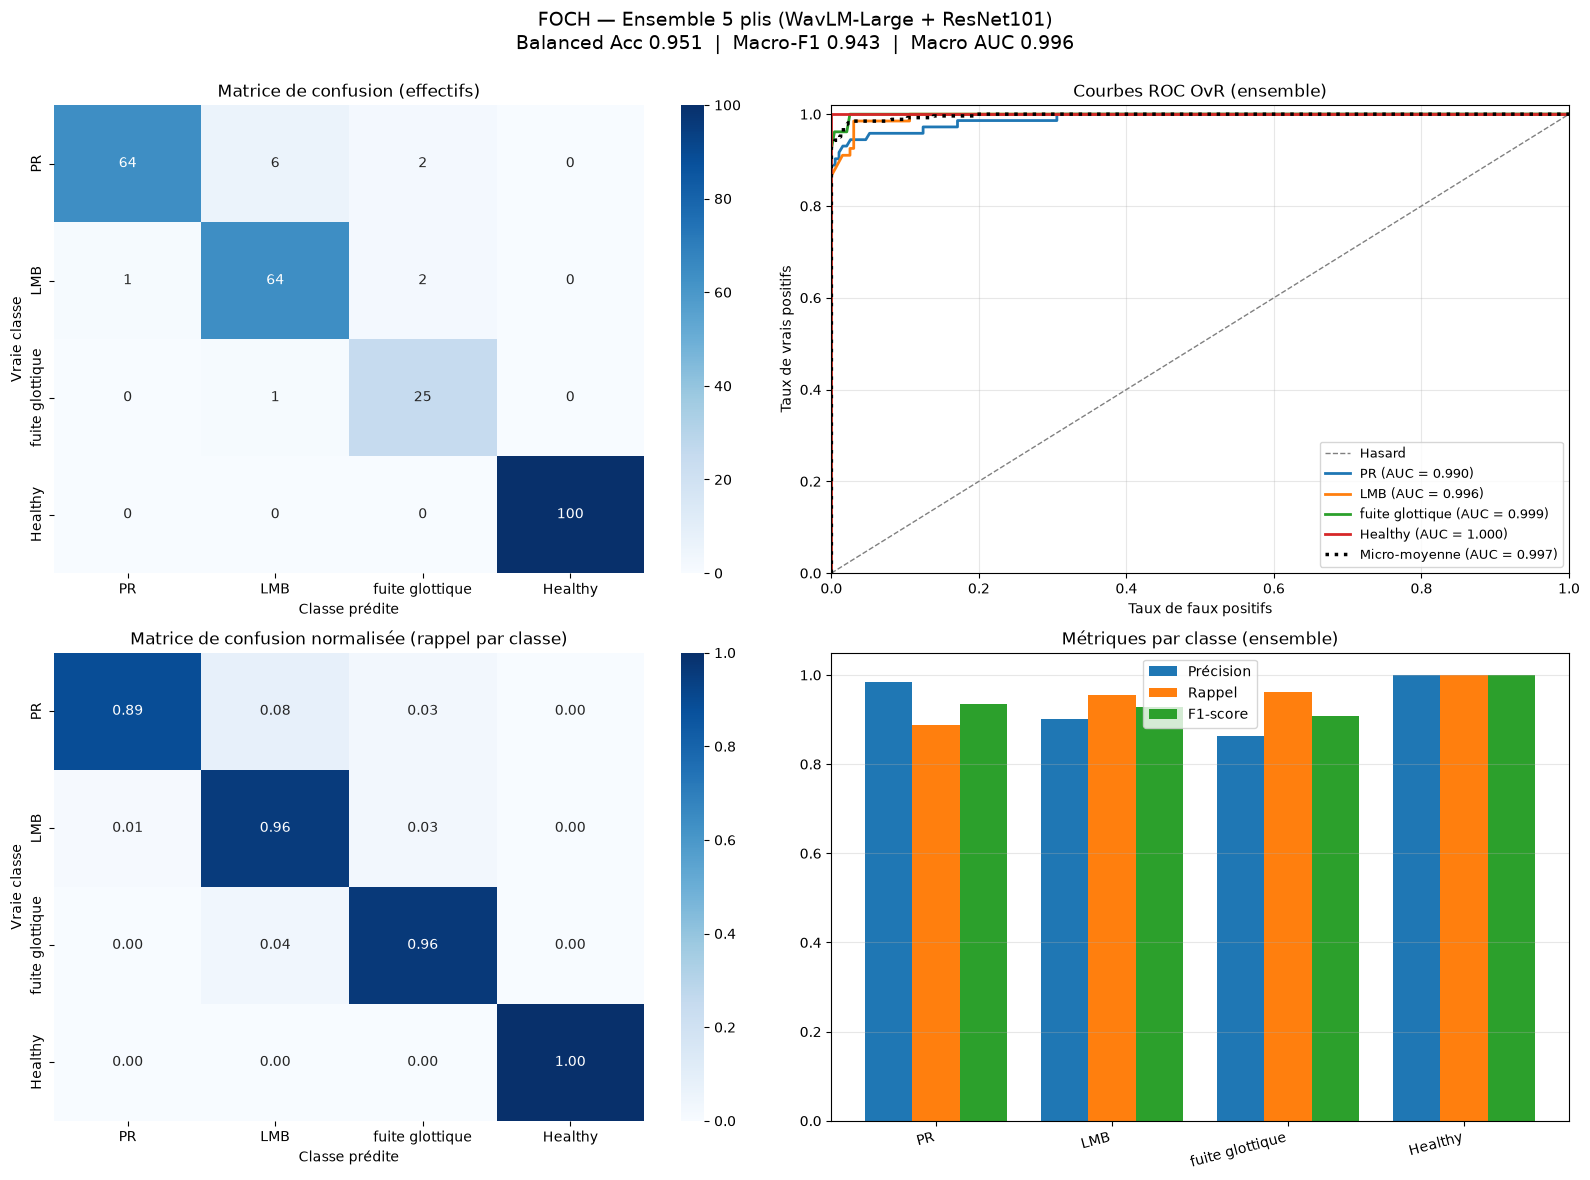

Dashboard sauvegardé : C:/Users/AdminIA/Documents/models/.foch_mètriques\wavlm_resnet101_kfold_specaug_ensemble_dashboard.png


In [9]:
# ═════════════════════════════════════════════════════════════════════════
# Cellule 9 — Inférence par ensemble des K plis
# ═════════════════════════════════════════════════════════════════════════
fold_checkpoints = [
    os.path.join(WEIGHTS_DIR, RUN_NAME + '_fold' + str(k + 1) + '_best.pt')
    for k in range(K_FOLDS)
]
missing = [p for p in fold_checkpoints if not os.path.exists(p)]
assert not missing, 'Checkpoint(s) manquant(s) : ' + str(missing)
print(str(K_FOLDS) + ' checkpoints détectés :')
for p in fold_checkpoints:
    print('  ' + p)


def ensemble_predict(dataloader, checkpoints, num_labels=NUM_LABELS):
    """Charge les K checkpoints et retourne la moyenne des probabilités softmax.

    Paramètres
    ----------
    dataloader  : DataLoader  — jeu à prédire (shuffle=False impératif)
    checkpoints : list[str]   — chemins des K fichiers .pt

    Retourne
    --------
    probs : np.ndarray (N, num_labels)  — probabilités moyennées
    """
    all_fold_probs = []
    for ckpt in checkpoints:
        m = build_model().to(device)
        m.load_state_dict(torch.load(ckpt, map_location=device))
        m.eval()
        fold_probs = []
        with torch.no_grad():
            for xb, mb, _ in dataloader:
                xb, mb = xb.to(device), mb.to(device)
                fold_probs.append(F.softmax(m(xb, mb), dim=1).cpu().numpy())
        all_fold_probs.append(np.concatenate(fold_probs))
        del m
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    return np.mean(all_fold_probs, axis=0)  # (N, num_labels)


# — Évaluation sur le jeu complet (démonstration) ————————————————————————————
full_loader = DataLoader(
    FochVowelDataset(df, processor),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True,
)
print('Inférence ensemble en cours (' + str(K_FOLDS) + ' modèles × ' + str(len(df)) + ' échantillons)...')
ens_probs   = ensemble_predict(full_loader, fold_checkpoints)
ens_preds   = ens_probs.argmax(1)
true_labels = df['label'].to_numpy()

ens_bal = balanced_accuracy_score(true_labels, ens_preds)
ens_mf1 = f1_score(true_labels, ens_preds, average='macro', zero_division=0)
ens_auc = roc_auc_score(true_labels, ens_probs, multi_class='ovr',
                        average='macro', labels=labels_idx)

print('\n' + '=' * 60)
print('Ensemble (5 plis) vs OOF individuel :')
print('=' * 60)
print('  Balanced Acc : {:.4f}  (OOF : {:.4f}  \u0394 {:+.4f})'.format(ens_bal, oof_bal, ens_bal - oof_bal))
print('  Macro-F1     : {:.4f}  (OOF : {:.4f}  \u0394 {:+.4f})'.format(ens_mf1, oof_mf1, ens_mf1 - oof_mf1))
print('  Macro AUC    : {:.4f}  (OOF : {:.4f}  \u0394 {:+.4f})'.format(ens_auc, oof_auc, ens_auc - oof_auc))
print('-' * 60)
print(classification_report(true_labels, ens_preds, labels=labels_idx,
                             target_names=CLASSES, digits=3, zero_division=0))

# ── Dashboard ensemble (2×2) ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'FOCH — Ensemble 5 plis (WavLM-Large + ResNet101)\n'
    'Balanced Acc {:.3f}  |  Macro-F1 {:.3f}  |  Macro AUC {:.3f}'.format(
        ens_bal, ens_mf1, ens_auc),
    fontsize=14)

# 1. Matrice de confusion (effectifs)
cm_ens = confusion_matrix(true_labels, ens_preds, labels=labels_idx)
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0, 0].set_title('Matrice de confusion (effectifs)')
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# 2. Courbes ROC OvR
y_bin_ens = label_binarize(true_labels, classes=labels_idx)
axes[0, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Hasard')
for i, class_name in enumerate(CLASSES):
    fpr_i, tpr_i, _ = roc_curve(y_bin_ens[:, i], ens_probs[:, i])
    auc_i = auc(fpr_i, tpr_i)
    axes[0, 1].plot(fpr_i, tpr_i, linewidth=2,
                    label='{} (AUC = {:.3f})'.format(class_name, auc_i))
fpr_micro, tpr_micro, _ = roc_curve(y_bin_ens.ravel(), ens_probs.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
axes[0, 1].plot(fpr_micro, tpr_micro, color='black', linewidth=2.5, linestyle=':',
                label='Micro-moyenne (AUC = {:.3f})'.format(auc_micro))
axes[0, 1].set_title('Courbes ROC OvR (ensemble)')
axes[0, 1].set_xlabel('Taux de faux positifs')
axes[0, 1].set_ylabel('Taux de vrais positifs')
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1.02)
axes[0, 1].legend(loc='lower right', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# 3. Matrice de confusion normalisée (rappel par classe)
cm_norm = cm_ens.astype(float) / cm_ens.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1, 0],
            xticklabels=CLASSES, yticklabels=CLASSES, vmin=0, vmax=1)
axes[1, 0].set_title('Matrice de confusion normalisée (rappel par classe)')
axes[1, 0].set_ylabel('Vraie classe')
axes[1, 0].set_xlabel('Classe prédite')

# 4. Précision / Rappel / F1 par classe
report_dict_ens = classification_report(
    true_labels, ens_preds, labels=labels_idx,
    target_names=CLASSES, output_dict=True, zero_division=0)
prec = [report_dict_ens[c]['precision'] for c in CLASSES]
rec  = [report_dict_ens[c]['recall']    for c in CLASSES]
f1s  = [report_dict_ens[c]['f1-score']  for c in CLASSES]
x    = np.arange(len(CLASSES))
w    = 0.27
axes[1, 1].bar(x - w, prec, w, label='Précision')
axes[1, 1].bar(x,     rec,  w, label='Rappel')
axes[1, 1].bar(x + w, f1s,  w, label='F1-score')
axes[1, 1].set_title('Métriques par classe (ensemble)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(CLASSES, rotation=15, ha='right')
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()
axes[1, 1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
ens_fig_path = os.path.join(METRICS_DIR, RUN_NAME + '_ensemble_dashboard.png')
plt.savefig(ens_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard sauvegardé : ' + ens_fig_path)

## 10. Synthèse et prochaines étapes

Ce notebook met en œuvre un **modèle de fusion bi-branche lourd** (WavLM-Large + ResNet101) évalué par **validation croisée stratifiée à 5 plis**, avec **augmentation de données** injectée pli par pli.

**Choix méthodologiques clés :**
- **Fusion de deux vues complémentaires** : embeddings WavLM 1024-d (microscopique) ⊕ ResNet101 2048-d sur Mel (macroscopique) → 3072-d.
- **Validation croisée K-Fold** (`StratifiedKFold`) : métriques agrégées out-of-fold + moyenne ± écart-type par pli, plus robustes qu'un découpage unique.
- **Augmentation sans fuite** : segments augmentés injectés **uniquement** dans le train de chaque pli, en excluant les patients du pli de validation.
- **Gestion mémoire** : modèle réinitialisé et cache CUDA vidé entre les plis (anti-OOM sur ResNet101).

**Pistes d'amélioration ultérieures :**
1. **Dégel progressif** de WavLM (*progressive unfreezing*).
2. **SpecAugment** sur la branche Mel.
3. **Pondération de fusion** apprise (attention) plutôt que simple concaténation.
4. **Ensembling** des K modèles de plis à l'inférence.
5. **Audit qualité** des doublons d'homonymes (`MARTIN`) via `patient_id`.

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 9). La Cellule 7 entraîne **K = 5 modèles** (WavLM-Large gelé + ResNet101) : prévoir un GPU CUDA et un temps d'exécution conséquent.